In [13]:
import pandas as pd

data_path = "../data/"

# loading x_train
data = pd.read_csv(data_path+'train_input_Z61KlZo.csv')
data.set_index('ID', inplace=True)
print("x_train", data.shape)

# loading target
target = pd.read_csv(data_path+'train_output_DzPxaPY.csv')
target.set_index('ID', inplace=True)
print("y_train", target.shape)

# joining x_train and y_train
data = data.join(target.drop("ANNEE_ASSURANCE", axis=1))
print("data", data.shape)

/var/folders/qf/pxq_c1s53jn0j_nkpfcjpxfm0000gn/T/ipykernel_10553/2176795849.py:6: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path+'train_input_Z61KlZo.csv')


x_train (383610, 373)
y_train (383610, 4)
data (383610, 376)


In [14]:
from AutoCarver import BinaryCarver
from sklearn.model_selection import train_test_split

target_col = "CM"

# loading target carver
target_carver = BinaryCarver.load("../data/cm_carver_freq_tschuprowt.json")

# discretizing the target
y_freq = target_carver.transform(data)[target_col]

# Train-test split
x_train, x_dev, y_train, y_dev = train_test_split(data, data[target_col], test_size=0.2, random_state=42, stratify=y_freq)
print("y_train mean", y_train.mean())
print("y_dev mean", y_dev.mean())

y_train mean 181.1602491223725
y_dev mean 187.96716387303076


In [15]:
print("amount mean per class")
y_train.groupby(target_carver.transform(x_train)[target_col]).mean().sort_index(), y_dev.groupby(target_carver.transform(x_dev)[target_col]).mean().sort_index()

amount mean per class


(CM
 0.0         0.043888
 1.0      6180.660202
 2.0    202026.255891
 Name: CM, dtype: float64,
 CM
 0.0         0.014288
 1.0      5502.732736
 2.0    213708.982759
 Name: CM, dtype: float64)

In [16]:
import warnings
from utils.data_toolkit import Processor

warnings.simplefilter(action='ignore', category=FutureWarning)

proc = Processor()
x_train = proc.fit_transform(x_train)
x_dev = proc.transform(x_dev)
data = proc.transform(data)
data.shape, x_train.shape, x_dev.shape

((383610, 562), (306888, 562), (76722, 562))

In [17]:
import numpy as np

# get the columns that are categorical
categorical_columns = x_train.select_dtypes(include=['object']).columns

# get the columns that are numerical
numerical_columns = x_train.select_dtypes(include=['int64', 'float64']).columns

# getting ordinal columns
ordinals = ["NB_CASERNES", "BDTOPO_BAT_MAX_HAUTEUR", "HAUTEUR_MAX", "HAUTEUR", "BDTOPO_BAT_MAX_HAUTEUR_MAX", "MEN_SURF", "IND_SNV", "IND_INC", "IND_Y9", "IND_0_Y1", "IND", "LOG_SOC", "LOG_INC", "LOG_APA3", "LOG_AVA1", "MEN_MAIS", "MEN_COLL", "MEN_FMP", "MEN_PROP", "MEN_PAUV", "MEN", "COEFASS"]
ordinals += ['DISTANCE_111', 'DISTANCE_112', 'DISTANCE_121', 'DISTANCE_122', 'DISTANCE_123', 'DISTANCE_124', 'DISTANCE_131', 'DISTANCE_132', 'DISTANCE_133', 'DISTANCE_141', 'DISTANCE_142', 'DISTANCE_211', 'DISTANCE_212', 'DISTANCE_213', 'DISTANCE_221', 'DISTANCE_222', 'DISTANCE_223', 'DISTANCE_231', 'DISTANCE_242', 'DISTANCE_243', 'DISTANCE_244', 'DISTANCE_311', 'DISTANCE_312', 'DISTANCE_313', 'DISTANCE_321', 'DISTANCE_322', 'DISTANCE_323', 'DISTANCE_324', 'DISTANCE_331', 'DISTANCE_332', 'DISTANCE_333', 'DISTANCE_334', 'DISTANCE_335', 'DISTANCE_411', 'DISTANCE_412', 'DISTANCE_421', 'DISTANCE_422', 'DISTANCE_423', 'DISTANCE_511', 'DISTANCE_512', 'DISTANCE_521', 'DISTANCE_522', 'DISTANCE_523', 'PROPORTION_11', 'PROPORTION_12', 'PROPORTION_13', 'PROPORTION_14', 'PROPORTION_21', 'PROPORTION_22', 'PROPORTION_23', 'PROPORTION_24', 'PROPORTION_31', 'PROPORTION_32', 'PROPORTION_33', 'PROPORTION_41', 'PROPORTION_42', 'PROPORTION_51', 'PROPORTION_52', 'MEN_1IND', 'MEN_5IND', 'LOG_A1_A2', 'LOG_A2_A3', 'IND_Y1_Y2', 'IND_Y2_Y3', 'IND_Y3_Y4', 'IND_Y4_Y5', 'IND_Y5_Y6', 'IND_Y6_Y7', 'IND_Y7_Y8', 'IND_Y8_Y9', 'DISTANCE_1', 'DISTANCE_2', 'ALTITUDE_1', 'ALTITUDE_2', 'ALTITUDE_3', 'ALTITUDE_4', 'ALTITUDE_5', 'NBJTX25_MM_A', 'NBJTX25_MMAX_A', 'NBJTX25_MSOM_A', 'NBJTX0_MM_A', 'NBJTX0_MMAX_A', 'NBJTX0_MSOM_A', 'NBJTXI27_MM_A', 'NBJTXI27_MMAX_A', 'NBJTXI27_MSOM_A', 'NBJTXS32_MM_A', 'NBJTXS32_MMAX_A', 'NBJTXS32_MSOM_A', 'NBJTXI20_MM_A', 'NBJTXI20_MMAX_A', 'NBJTXI20_MSOM_A', 'NBJTX30_MM_A', 'NBJTX30_MMAX_A', 'NBJTX30_MSOM_A', 'NBJTX35_MM_A', 'NBJTX35_MMAX_A', 'NBJTX35_MSOM_A', 'NBJTN10_MM_A', 'NBJTN10_MMAX_A', 'NBJTN10_MSOM_A', 'NBJTNI10_MM_A', 'NBJTNI10_MMAX_A', 'NBJTNI10_MSOM_A', 'NBJTN5_MM_A', 'NBJTN5_MMAX_A', 'NBJTN5_MSOM_A', 'NBJTNS25_MM_A', 'NBJTNS25_MMAX_A', 'NBJTNS25_MSOM_A', 'NBJTNI15_MM_A', 'NBJTNI15_MMAX_A', 'NBJTNI15_MSOM_A', 'NBJTNI20_MM_A', 'NBJTNI20_MMAX_A', 'NBJTNI20_MSOM_A', 'NBJTNS20_MM_A', 'NBJTNS20_MMAX_A', 'NBJTNS20_MSOM_A', 'NBJTMS24_MM_A', 'NBJTMS24_MMAX_A', 'NBJTMS24_MSOM_A', 'TAMPLIAB_VOR_MM_A', 'TAMPLIAB_VOR_MMAX_A', 'TAMPLIM_VOR_MM_A', 'TAMPLIM_VOR_MMAX_A', 'TM_VOR_MM_A', 'TM_VOR_MMAX_A', 'TMM_VOR_MM_A', 'TMM_VOR_MMAX_A', 'TMMAX_VOR_MM_A', 'TMMAX_VOR_MMAX_A', 'TMMIN_VOR_MM_A', 'TMMIN_VOR_MMAX_A', 'TN_VOR_MM_A', 'TN_VOR_MMAX_A', 'TNAB_VOR_MM_A', 'TNAB_VOR_MMAX_A', 'TNMAX_VOR_MM_A', 'TNMAX_VOR_MMAX_A', 'TX_VOR_MM_A', 'TX_VOR_MMAX_A', 'TXAB_VOR_MM_A', 'TXAB_VOR_MMAX_A', 'TXMIN_VOR_MM_A', 'TXMIN_VOR_MMAX_A', 'NBJFF10_MM_A', 'NBJFF10_MMAX_A', 'NBJFF10_MSOM_A', 'NBJFF16_MM_A', 'NBJFF16_MMAX_A', 'NBJFF16_MSOM_A', 'NBJFF28_MM_A', 'NBJFF28_MMAX_A', 'NBJFF28_MSOM_A', 'NBJFXI3S10_MM_A', 'NBJFXI3S10_MMAX_A', 'NBJFXI3S10_MSOM_A', 'NBJFXI3S16_MM_A', 'NBJFXI3S16_MMAX_A', 'NBJFXI3S16_MSOM_A', 'NBJFXI3S28_MM_A', 'NBJFXI3S28_MMAX_A', 'NBJFXI3S28_MSOM_A', 'NBJFXY8_MM_A', 'NBJFXY8_MMAX_A', 'NBJFXY8_MSOM_A', 'NBJFXY10_MM_A', 'NBJFXY10_MMAX_A', 'NBJFXY10_MSOM_A', 'NBJFXY15_MM_A', 'NBJFXY15_MMAX_A', 'NBJFXY15_MSOM_A', 'FFM_VOR_MM_A', 'FFM_VOR_MMAX_A', 'FXI3SAB_VOR_MM_A', 'FXI3SAB_VOR_MMAX_A', 'FXIAB_VOR_MM_A', 'FXIAB_VOR_MMAX_A', 'FXYAB_VOR_MM_A', 'FXYAB_VOR_MMAX_A', 'FFM_VOR_COM_MM_A_Y', 'FFM_VOR_COM_MMAX_A_Y', 'FXI3SAB_VOR_COM_MM_A_Y', 'FXI3SAB_VOR_COM_MMAX_A_Y', 'NBJRR50_MM_A', 'NBJRR50_MMAX_A', 'NBJRR50_MSOM_A', 'NBJRR1_MM_A', 'NBJRR1_MMAX_A', 'NBJRR1_MSOM_A', 'NBJRR5_MM_A', 'NBJRR5_MMAX_A', 'NBJRR5_MSOM_A', 'NBJRR10_MM_A', 'NBJRR10_MMAX_A', 'NBJRR10_MSOM_A', 'NBJRR30_MM_A', 'NBJRR30_MMAX_A', 'NBJRR30_MSOM_A', 'NBJRR100_MM_A', 'NBJRR100_MMAX_A', 'NBJRR100_MSOM_A', 'RR_VOR_MM_A', 'RR_VOR_MMAX_A', 'RRAB_VOR_MM_A', 'RRAB_VOR_MMAX_A']
# ordinals += ["AN_EXERC"]
ordinals += ["TAILLE1", "TAILLE2"]
ordinal_columns = {
    col: list(data[col].value_counts().sort_index().index)
    for col in ordinals
    if col in data.columns
}
ordinal_columns["PROPORTION_32"] += ['10. > 90']
ordinal_columns.update(
    {
        "CARACT4": ['absence de surface', 'Surface de moins d', 'Surface entre 501', 'Surface entre 1001', 'Surface entre 1501', 'Surface de plus de'],
        'SURFACE4': ['0', '500', '1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000', '5500', '6000', '6500', '7000', '7000+'],
        'SURFACE6': ['0', '500', '1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000', '5500', '6000', '6500', '7000', '7000+'],
        'total_surface_2023': ['Aucun feu', '<10ha', '10-20ha', '20-50ha', '50-100ha', '100-200ha', '>200ha'],
        'total_surface_5y': ['Aucun feu', '<10ha', '10-20ha', '20-50ha', '50-100ha', '100-200ha', '>200ha'],
        'surface_over_forest': ['Absence de feu', '<0.05', '0.05-0.1', '0.1-0.2', '0.5-2'],
        'fire_extinction_rates': ['Aucun feu', '<50%', '50-70%', '70-85%', '>85%'],
    }
)

# get the columns that are to be removed
to_remove = target.columns.tolist() + [target_col]
to_remove += [c for c in data.columns if "MMSOM" in c]
to_remove += ["DEROG3", "DEROG13", "DEROG16", "DEROG8", 'DEROG14', "TARGET"]  # no values
to_remove += ["DEROG13_formatted", "DEROG8_formatted", "DEROG3_formatted", "DEROG16_formatted", "DEROG14_formatted"]
to_remove += ["IND_Y1_Y2_num", "IND_INC_num"]

# removing columns
categorical_columns = [col for col in categorical_columns if col not in to_remove and col not in ordinal_columns]
categorical_columns += ["TYPERS"]
numerical_columns = [col for col in numerical_columns if col not in to_remove and col not in ordinal_columns and col not in categorical_columns]
print(len(categorical_columns), len(numerical_columns), len(ordinal_columns), len(categorical_columns)+ len(numerical_columns)+ len(ordinal_columns))

89 219 238 546


### Load carver of this model

In [18]:
from AutoCarver import ContinuousCarver

version = "018"
carver = ContinuousCarver.load(f"../data/{version}_carver.json")
carver.summary

content  \
feature                          label                                                      
Categorical('ACTIVIT2')          0                                                   ACT2   
                                 1      [ACT5, ACT4, ACT6, ACT7, ACT9, ACT3, ACT8, __O...   
                                 2                                                   ACT1   
Categorical('VOCATION')          0              [VOC7, VOC5, VOC3, VOC2, __OTHER__, VOC8]   
                                 1                                                   VOC1   
...                                                                                   ...   
Ordinal('total_surface_5y')      0                                     [<10ha, Aucun feu]   
                                 1                                     [20-50ha, 10-20ha]   
                                 2                          [100-200ha, >200ha, 50-100ha]   
Ordinal('fire_extinction_rates') 0                      [<50%, 50-70%, 70-85%, Aucun feu]   
                                 1                                                   >85%   

                                        target_mean  frequency  
feature                          label                          
Categorical('ACTIVIT2')          0        69.750884   0.037225  
                                 1       157.138481   0.189379  
                                 2       189.147584   0.773396  
Categorical('VOCATION')          0        41.628900   0.285286  
                                 1        69.750884   0.037225  
...                                             ...        ...  
Ordinal('total_surface_5y')      0       167.873441   0.400648  
                                 1       191.128641   0.268860  
                                 2       181.535885   0.330492  
Ordinal('fire_extinction_rates') 0       156.601832   0.743216  
                                 1       242.430061   0.256784  

[742 rows x 3 columns]

In [19]:
x_train = carver.transform(x_train)
x_dev = carver.transform(x_dev)

In [20]:
x_train

,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,...,Malveillance,Naturelle,VENT_x_CASERNES,KAPITAL_SUM,KAPITAL_MAX,DEROG13_formatted,DEROG8_formatted,DEROG3_formatted,DEROG16_formatted,DEROG14_formatted
ID,,,,,,,,,,,,,,,,,,,,,
81801,1,3,1,3,N,1.0,NaN,NaN,N,2.0,...,45.0,75.0,0.0,189500.0,125000.0,0,0,0,0,0
305126,2,0,0,11,N,0.0,NaN,NaN,N,2.0,...,3.0,0.0,1.0,5000.0,5000.0,0,0,0,0,0
142195,2,0,0,0,N,1.0,NaN,NaN,N,2.0,...,0.0,0.0,0.0,5000.0,5000.0,0,0,0,0,0
221453,1,2,1,8,N,0.0,1.0,O,O,10.0,...,111.0,8.0,0.0,825000.0,225000.0,0,0,0,0,0
123515,1,3,1,2,N,1.0,NaN,NaN,N,2.0,...,0.0,0.0,0.0,313002.0,175000.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106561,2,0,0,5,N,1.0,NaN,NaN,N,2.0,...,1.0,0.0,0.0,1000.0,1000.0,0,0,0,0,0
289942,2,3,1,1,O,1.0,NaN,NaN,N,2.0,...,2.0,2.0,0.0,756000.0,175000.0,0,0,0,0,0
102520,2,0,0,5,N,0.0,NaN,NaN,N,2.0,...,1.0,1.0,0.0,1000.0,1000.0,0,0,0,0,0


### Load model 

In [21]:
### Loading model
import json
from xgboost import XGBRegressor

model = XGBRegressor()
model.load_model(data_path+'019_xgboost.json')


best_features = json.load(open(f"../data/018_best_features.json"))
best_features

['SURFACE11',
 'KAPITAL32',
 'SURFACE17',
 'KAPITAL_MAX',
 'SURFACE10',
 'NBBAT1',
 'KAPITAL21',
 'KAPITAL10',
 'CA3_CA_MEAN',
 'EQUIPEMENT6',
 'SURFACE7',
 'KAPITAL24',
 'NBSINSTRT',
 'CA3',
 'KAPITAL27',
 'SURFACE8',
 'KAPITAL23',
 'KAPITAL3',
 'KAPITAL14',
 'NBBAT8',
 'DEROG11',
 'RISK5',
 'RISK4',
 'RISK1',
 'RISK3',
 'ALTITUDE_5_ALT_TOT',
 'NBSINCONJ',
 'ALTITUDE_2_ALT_TOT',
 'NBBAT6',
 'CARACT5',
 'KAPITAL26',
 'DEROG10',
 'NBBAT9',
 'KAPITAL28',
 'CARACT2',
 'KAPITAL8',
 'EQUIPEMENT1',
 'KAPITAL18',
 'TAILLE3',
 'ALTITUDE_4_num',
 'IND_Y5_Y6_num',
 'KAPITAL25',
 'ALTITUDE_3_num',
 'IND_Y5_Y6_IND_SNV',
 'ANCIENNETE',
 'DEROG1',
 'ALTITUDE_REGION',
 'CA3_CA_TOT',
 'KAPITAL17',
 'DEROG6',
 'KAPITAL16',
 'KAPITAL_SUM',
 'SURFACE1',
 'KAPITAL12',
 'NBBAT4',
 'NBBAT10',
 'RISK2',
 'ALTITUDE_2_num',
 'IND_Y5_Y6_IND',
 'SURFACE4',
 'TAILLE1',
 'TAILLE2',
 'KAPITAL40',
 'VOCATION',
 'TYPERS',
 'KAPITAL41',
 'KAPITAL42',
 'RISK11',
 'KAPITAL37',
 'KAPITAL43',
 'ACTIVIT2',
 'DEROG4',
 'DER

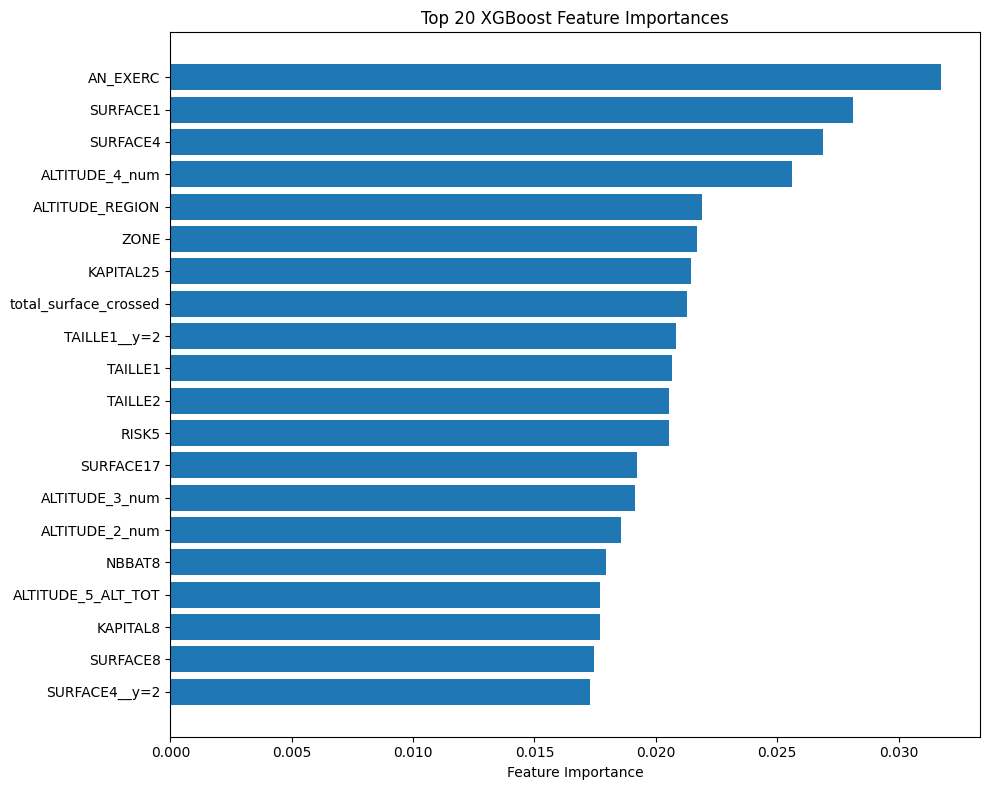

In [27]:
import numpy as np

import matplotlib.pyplot as plt

# Get indices of top 30 features by importance
top_idx = np.argsort(importances)[-20:][::-1]
top_features = features[top_idx]
top_importances = importances[top_idx]

plt.figure(figsize=(10, 8))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()